In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df_test = pd.read_csv('olist_orders_dataset.csv')

print(df_test.head())


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [24]:
#Check for missing values 
print(df_test.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [25]:
#Check for duplicates
print(f"Duplicate rows: {df_test.duplicated().sum()}")

#  Check Data Types
print(df_test.info())

Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None


### convert all timestamp columns to actual datetime objects

In [26]:
# List of columns that should be dates
date_columns = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

# Convert them
for col in date_columns:
    df_test[col] = pd.to_datetime(df_test[col])

print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB
None


### 2,965 nulls in order_delivered_customer_date
#### For a logistics performance report,  cannot calculate "actual delivery time" for an order that hasn't arrived. We should filter for order_status == 'delivered'.

In [27]:
# Keep only delivered orders for performance analysis
df_delivered = df_test[df_test['order_status'] == 'delivered'].copy()

# Drop any remaining rows where the delivery date is missing 
df_delivered = df_delivered.dropna(subset=['order_delivered_customer_date'])

print(f"Cleaned dataset size: {df_delivered.shape[0]} orders")

Cleaned dataset size: 96470 orders


In [28]:
df_delivered.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64

### Feature Engineering (Logistics Metrics)

In [29]:
# 1. Actual Delivery Time (in days)
df_delivered['actual_delivery_days'] = (df_delivered['order_delivered_customer_date'] - df_delivered['order_purchase_timestamp']).dt.days

# 2. Estimated Delivery Time (in days)
df_delivered['estimated_delivery_days'] = (df_delivered['order_estimated_delivery_date'] - df_delivered['order_purchase_timestamp']).dt.days

# 3. Delivery Error (Positive = Late, Negative = Early)
df_delivered['days_diff'] = df_delivered['actual_delivery_days'] - df_delivered['estimated_delivery_days']

# 4. Create a Binary Status for Power BI (On-Time vs Late)
df_delivered['is_late'] = df_delivered['days_diff'] > 0
df_delivered['delivery_status'] = df_delivered['is_late'].map({True: 'Late', False: 'On-Time'})

print(df_delivered[['actual_delivery_days', 'estimated_delivery_days', 'delivery_status']].head())

   actual_delivery_days  estimated_delivery_days delivery_status
0                     8                       15         On-Time
1                    13                       19         On-Time
2                     9                       26         On-Time
3                    13                       26         On-Time
4                     2                       12         On-Time


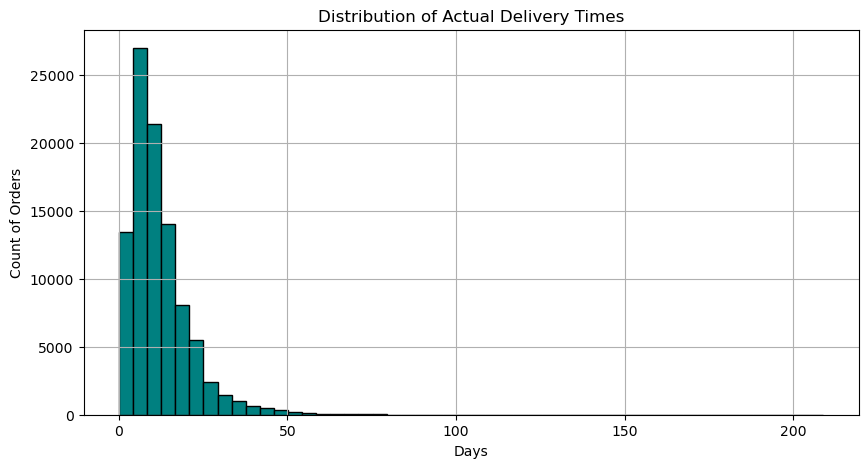

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
df_delivered['actual_delivery_days'].hist(bins=50, color='teal', edgecolor='black')
plt.title('Distribution of Actual Delivery Times')
plt.xlabel('Days')
plt.ylabel('Count of Orders')
plt.show()

In [31]:
# Load the other necessary files
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

In [32]:
# Translate Product Categories immediately
products = products.merge(translation, on='product_category_name', how='left')
# Use the English name, fall back to Portuguese if translation is missing
products['category'] = products['product_category_name_english'].fillna(products['product_category_name'])

In [33]:
# Start merging into df_delivered
# Join Items first (This adds Price and Freight)
master_df = df_delivered.merge(items[['order_id', 'product_id', 'price', 'freight_value']], on='order_id', how='left')

In [34]:
# Join Products (This adds the Category)
master_df = master_df.merge(products[['product_id', 'category']], on='product_id', how='left')

# Join Customers (This adds State and City for the maps)
master_df = master_df.merge(customers[['customer_id', 'customer_city', 'customer_state']], on='customer_id', how='left')

In [35]:
# Final Check
print(f"Final columns: {master_df.columns.tolist()}")
print(f"Missing categories: {master_df['category'].isnull().sum()}")
master_df.head()

Final columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'actual_delivery_days', 'estimated_delivery_days', 'days_diff', 'is_late', 'delivery_status', 'product_id', 'price', 'freight_value', 'category', 'customer_city', 'customer_state']
Missing categories: 1537


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,actual_delivery_days,estimated_delivery_days,days_diff,is_late,delivery_status,product_id,price,freight_value,category,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,15,-7,False,On-Time,87285b34884572647811a353c7ac498a,29.99,8.72,housewares,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,19,-6,False,On-Time,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumery,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,26,-17,False,On-Time,aa4383b373c6aca5d8797843e5594415,159.90,19.22,auto,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,26,-13,False,On-Time,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,pet_shop,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,12,-10,False,On-Time,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,stationery,santo andre,SP


### Handling the 1,537 Missing Categories

In [36]:
# Fill missing categories with 'Unknown' so they are easy to filter in Power BI
master_df['category'] = master_df['category'].fillna('other/unknown')
master_df.to_csv('olist_final_for_powerbi.csv', index=False)

### Detecting Anomalies

Orders with negative delivery days: 0


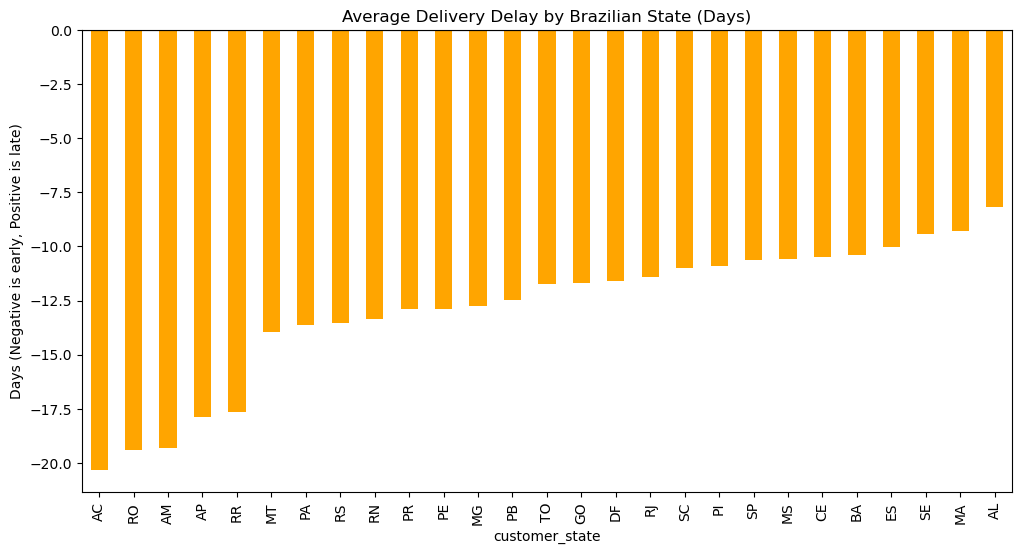

In [37]:
# Check for negative delivery days (Data entry errors)
errors = master_df[master_df['actual_delivery_days'] < 0]
print(f"Orders with negative delivery days: {len(errors)}")

# If there are any,  filter them out to keep the dashboard accurate
master_df = master_df[master_df['actual_delivery_days'] >= 0]

# Quick Plot: Average Delay by State
plt.figure(figsize=(12, 6))
master_df.groupby('customer_state')['days_diff'].mean().sort_values().plot(kind='bar', color='orange')
plt.title('Average Delivery Delay by Brazilian State (Days)')
plt.ylabel('Days (Negative is early, Positive is late)')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

### Enhanced Feature Engineering for powerbi KPIs, charts, numeric measures.

In [38]:
# 1. Total Revenue (Price + Freight)
master_df['total_revenue'] = master_df['price'] + master_df['freight_value']

# 2. Temporal Features for Seasonal Analysis
master_df['order_year'] = master_df['order_purchase_timestamp'].dt.year
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.month
master_df['order_month_name'] = master_df['order_purchase_timestamp'].dt.strftime('%b') # 'Jan', 'Feb', etc.

# 3. Numeric Late Flag (Essential for Average Calculations in Power BI)
master_df['late_flag'] = master_df['is_late'].astype(int)

# 4. Preview Top Categories (Sanity check for report)
top_categories = master_df.groupby('category')['price'].sum().sort_values(ascending=False).head(10)
print("--- Top 10 Categories by Revenue ---")
print(top_categories)

# Final Save
master_df.to_csv('olist_final_for_powerbi.csv', index=False)

--- Top 10 Categories by Revenue ---
category
health_beauty            1233131.72
watches_gifts            1165898.98
bed_bath_table           1023434.76
sports_leisure            954673.55
computers_accessories     888613.62
furniture_decor           711927.69
housewares                615628.69
cool_stuff                610204.10
auto                      578849.35
toys                      471097.49
Name: price, dtype: float64
